In [ ]:
import torch
from kan import KAN

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.19e-03 | test_loss: 1.25e-03 | reg: 1.39e+01 | : 100%|█| 20/20 [00:03<00:00,  6.27it


saving model version 0.1
saving model version 0.2


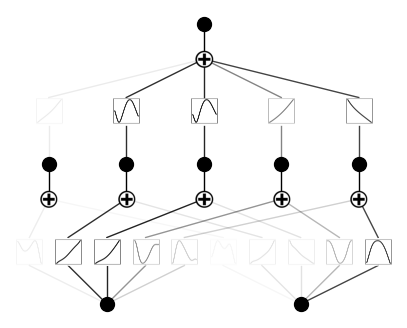

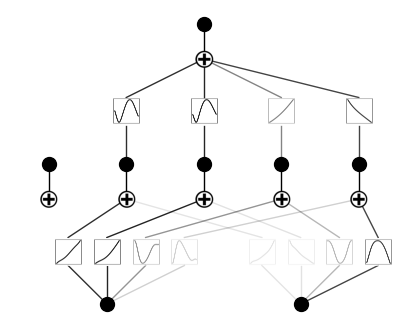

In [10]:
# 1. Define the target function
f = lambda x: torch.sin(torch.pi * x[:, [0]]) + x[:, [1]]**2

# 2. Create a dataset
# n_var specifies the number of input variables
# create_dataset is a helper function from pykan
from kan.utils import create_dataset 
dataset = create_dataset(f, n_var=2)

# 3. Initialize the KAN model
# width: defines the architecture (e.g., [2, 5, 1] means 2 inputs, 5 hidden neurons, 1 output)
# grid: number of grid intervals for the splines
# k: order of piecewise polynomial
model = KAN(width=[2,5,1], grid=5, k=3)

# 4. Train the KAN model
# opt: optimizer (e.g., 'LBFGS' or 'Adam')
# steps: number of training steps
# lamb: regularization parameter for sparsity (optional)
results = model.fit(dataset, opt='LBFGS', steps=20)

# 5. Visualize the KAN model
# This will plot the learned functions for each connection
model.plot()

# 6. (Optional) Prune the model for interpretability
pruned_model = model.prune()
pruned_model.plot()

# 7. (Optional) Auto-symbolic regression for interpreting the functions
# lib = ['x', 'x^2', 'exp', 'sin', 'log']
# model.auto_symbolic(lib=lib)
# formula = model.symbolic_formula()
# print(formula)
